In [1]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
import matplotlib.pyplot as plt
from word2number import w2n
from dotenv import load_dotenv
import copy
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch
import io

/Users/wt/PythonProjects/Multi_Agent_Cartoon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [2]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "simpsons")

# Set paths relative to base_dir
annotation_path = os.path.join(base_dir, "v1_Annotation_Val_simpsons_vqa.json")
question_path = os.path.join(base_dir, "v1_Question_Val_simpsons_vqa.json")
images_dir = os.path.join(base_dir, "val_images")

def load_dataset(annotation_path, question_path):
    try:
        with open(annotation_path, 'r') as f:
            annotations = json.load(f)['annotations']

        with open(question_path, 'r') as f:
            questions = json.load(f)['questions']

        # Select high-quality QA pairs (overall_scores == 1.0)
        filtered_annotations = [
            annotation for annotation in annotations
            if annotation.get('overall_scores', {}).get('question') == 1.0 and
               annotation.get('overall_scores', {}).get('answer') == 1.0
        ]

        # Create a mapping from question ID to answer
        question_id_to_answer = {
            annotation['id']: annotation['answer']
            for annotation in filtered_annotations
        }

        # Create a mapping from question ID to answer type
        question_id_to_answer_type = {
            annotation['id']: {
                'answer': annotation['answer'],
                'answer_type': annotation.get('answer_type', 'other')
            }
            for annotation in filtered_annotations
        }

        filtered_questions = [question for question in questions if question['id'] in question_id_to_answer]

        return filtered_questions, filtered_annotations, question_id_to_answer, question_id_to_answer_type

    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], [], {}, {}

def get_dataset(questions, question_id_to_answer, fraction=0.005, seed=42):
    # TODO: Increase quantity
# def get_dataset(questions, question_id_to_answer, fraction=0.05, seed=42):
    try:
        random.seed(seed)
        sample_size = max(1, int(len(questions) * fraction))
        sampled_question_items = random.sample(questions, sample_size)
        sampled_correct_answers = [
            question_id_to_answer[q['id']]
            for q in sampled_question_items
        ]
        # Add image_base64 to each sampled question
        for q in sampled_question_items:
            image_relative_path = q['img_path']
            image_path = os.path.join(images_dir, image_relative_path)
            q['image_base64'] = encode_image(image_path)

        return sampled_question_items, sampled_correct_answers

    except Exception as e:
        print(f"Error sampling dataset: {e}")
        return [], []

def encode_image(image_path):
    try:
        if not os.path.exists(image_path):
            print(f"Error: The image file at {image_path} was not found.")
            return None

        with open(image_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode('utf-8')
            return image_base64

    except Exception as e:
        print(f"An error occurred while encoding the image: {e}")
        return None

# Initialize results list
results_ablation = []
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    global cached_dataset
    if cached_dataset is None or reload:
        # Load the dataset from disk
        questions, annotations, question_id_to_answer, question_id_to_answer_type = load_dataset(annotation_path, question_path)
        cached_dataset = {
            'questions': questions,
            'annotations': annotations,
            'question_id_to_answer': question_id_to_answer,
            'question_id_to_answer_type': question_id_to_answer_type
        }
    else:
        print("Using cached dataset but creating a deep copy to prevent contamination...")

    # Always return a deep copy to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['questions']), \
           copy.deepcopy(cached_dataset['annotations']), \
           copy.deepcopy(cached_dataset['question_id_to_answer']), \
           copy.deepcopy(cached_dataset['question_id_to_answer_type'])

# Ablation Study Configuration
# Global variables for agent enablement, initialized here
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False



# Agents Configuration

In [3]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# BLIP-2 Model Initialization
print("Initializing BLIP-2 model...")

# Detect and set MPS device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Metal Performance Shaders) acceleration")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Load BLIP-2 model
blip2_model_name = "Salesforce/blip2-flan-t5-xl"
blip2_processor = Blip2Processor.from_pretrained(
    blip2_model_name,
    use_fast=True
)

blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    blip2_model_name,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
    device_map={"": device}
)

print(f"BLIP-2 model loaded successfully on {device}")

# Agent Implementations

# Enhanced Visual agent using BLIP-2 for direct visual question answering
def visual_agent(image_base64, question, max_retries=3, retry_delay=2):
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from The Simpsons."

    def clean_repeated_words(text):
        """
        Clean repeated words and characters in text, keeping the first occurrence of each consecutive repeated word sequence
        Example: "a satanic satanic satanic" -> "a satanic"
                 "eeeeeeee" -> "e"
        """
        if not text or not isinstance(text, str):
            return text
        
        # First check if it's single character repetition (like "eeeeeee")
        # If so, directly return that character
        if len(text) > 5:
            unique_chars = set(text.replace(' ', ''))
            if len(unique_chars) == 1 and len(text) > 3:
                # All the same character, return single occurrence of that character
                return list(unique_chars)[0]
        
        words = text.split()
        if len(words) <= 1:
            return text
        
        # Remove consecutive repeated words
        cleaned_words = [words[0]]
        for i in range(1, len(words)):
            # Only add if current word is different from previous word
            if words[i].lower() != words[i-1].lower():
                cleaned_words.append(words[i])
        
        cleaned_text = ' '.join(cleaned_words)
        
        # Additional processing: detect repeated phrase patterns (like "a frog and a frog and")
        # If obvious phrase repetition is detected, further clean it
        words_after_first_clean = cleaned_text.split()
        if len(words_after_first_clean) >= 6:
            # Try to detect 2-4 word repeated phrase patterns
            for pattern_len in range(2, min(5, len(words_after_first_clean) // 2 + 1)):
                pattern = ' '.join(words_after_first_clean[:pattern_len])
                # Count how many times this pattern appears in the text
                pattern_count = cleaned_text.count(pattern)
                
                # If phrase repeats 3 or more times, keep only first occurrence
                if pattern_count >= 3:
                    # Find the position of first occurrence
                    first_occurrence_end = cleaned_text.index(pattern) + len(pattern)
                    # Keep only up to the first occurrence
                    cleaned_text = cleaned_text[:first_occurrence_end].strip()
                    break
        
        return cleaned_text
    
    def is_valid_answer(text):
        """
        Check if BLIP2 answer is valid
        Note: This function only detects truly invalid output, not repetitions (repetitions are handled by clean_repeated_words)
        """
        if not text or not isinstance(text, str) or len(text.strip()) == 0:
            return False
        
        text = text.strip().lower()
        
        # Strategy 1: Detect extremely short output
        if len(text) < 3:
            return False
        
        # Strategy 2: Detect completely composed of single character (like "eeeeee")
        unique_chars = set(text.replace(' ', ''))
        if len(unique_chars) == 1:
            return False
        
        # Strategy 3: For longer text, use character ratio detection
        # If a character accounts for more than 70% of all letters, consider it a repeated character error
        if len(text) > 5:
            char_counts = {}
            for char in text:
                if char.isalpha():  # Only count letters
                    char_counts[char] = char_counts.get(char, 0) + 1
            
            if char_counts:
                max_count = max(char_counts.values())
                total_alpha = sum(char_counts.values())
                
                # Character ratio exceeding 70% is considered invalid
                if total_alpha > 0 and (max_count / total_alpha) > 0.7:
                    return False
        
        return True

    try:
        # Decode base64 image
        image_bytes = base64.b64decode(image_base64)
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
        
        for attempt in range(max_retries):
            try:
                # Use BLIP-2 to directly answer question
                prompt = f"Question: {question}"
                
                with torch.no_grad():
                    inputs = blip2_processor(images=image, text=prompt, return_tensors="pt")
                    inputs = {k: v.to(device) for k, v in inputs.items()}
                    
                    generated_ids = blip2_model.generate(
                        **inputs, 
                        max_new_tokens=80,
                        do_sample=False
                    )
                    
                    answer = blip2_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
                    
                    # Clean up BLIP2 output - remove common prefixes
                    prefixes_to_remove = ['answer:', 'Answer:', 'ANSWER:', 'the answer is:', 'The answer is:']
                    for prefix in prefixes_to_remove:
                        if answer.lower().startswith(prefix.lower()):
                            answer = answer[len(prefix):].strip()
                            break
                    
                    # Step 1: Clean repeated words
                    cleaned_answer = clean_repeated_words(answer)
                    
                    # Step 2: Verify if cleaned answer is valid
                    if not is_valid_answer(cleaned_answer):
                        print(f"Warning: Invalid BLIP2 answer after cleaning: '{answer[:80]}...' -> '{cleaned_answer[:80]}...'")
                        return "This is a cartoon image from The Simpsons."
                    
                    # If cleaned answer differs from original answer, it means repetitions were removed
                    if cleaned_answer != answer:
                        print(f"Cleaned repeated words: '{answer[:80]}...' -> '{cleaned_answer}'")
                    
                    # If answer is empty, return default description
                    if not cleaned_answer or cleaned_answer.lower() in ['', 'none', 'nothing']:
                        return "This is a cartoon image from The Simpsons."
                    
                    return cleaned_answer

            except Exception as e:
                print(f"BLIP-2 visual agent attempt {attempt + 1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                continue

        print("Error: BLIP-2 visual agent failed to process the image")
        return "This is a cartoon image from The Simpsons."
        
    except Exception as e:
        print(f"Error in BLIP-2 visual agent: {e}")
        import traceback
        traceback.print_exc()
        return "This is a cartoon image from The Simpsons."

# Language agent: handles questions, and outputs pure or visual language answers
def language_agent(question, image_base64, visual_description, max_retries=3, retry_delay=2):
    if not ENABLE_LANGUAGE_AGENT:
        return None

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."

    prompt = f"""
    As a cartoon language agent, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE WORD:

    Evidence: 
    Visual Description: "{visual_description}"

    Guidelines: 
    - No explanations or punctuation allowed.
    - Do not answer "none", "n/a", "unknown" even if you are uncertain. Always attempt a plausible reasonable answer.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=150,
                    temperature=0.0,
                )
                answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.0,
                )
                answer = completion.content[0].text.strip().lower()

            # Process the response
            answer = answer.rstrip('.!?') 
            words = answer.split()
            if not words:
                continue

            answer = words[0]  

            # Convert numbers if applicable
            try:
                number = w2n.word_to_num(answer)
                answer = str(number)
            except ValueError:
                matches = re.findall(r'\d+', answer)
                if matches:
                    answer = matches[0]

            return answer

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

def classify_question_type(question):
    question_lower = question.lower()

    # Color questions
    if any(word in question_lower for word in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'

    # Counting/numeric questions
    elif any(word in question_lower for word in ['how many', 'count', 'number']):
        return 'counting'

    # Action questions
    elif any(word in question_lower for word in ['doing', 'action', 'what is', 'what are', 'activity']):
        return 'action recognition'

    # Existence questions
    elif any(word in question_lower for word in ['is there', 'are there', 'does', 'do you see', 'can you']):
        return 'existence'

    # Location questions
    elif any(word in question_lower for word in ['where', 'location', 'place', 'position', 'on the', 'in the']):
        return 'location'

    # Default
    return 'other'

def critic_agent(question, image_base64, pure_language_answer, visual_language_answer, visual_description, max_retries=3, retry_delay=2, verbose=False):
    if not ENABLE_CRITIC_AGENT:
        return (visual_language_answer if ENABLE_VISUAL_AGENT else pure_language_answer), False, {}

    # Validate correct inputs are available for each configuration
    if ENABLE_VISUAL_AGENT:  # visual_language_critic
        # Visual + Language + Critic needs both pure and visual language answers
        if pure_language_answer is None:
            pure_language_answer = ""  
            
        if visual_language_answer is None:
            visual_language_answer = ""  
            
        if visual_description is None or visual_description == "This is a cartoon image from The Simpsons.":
            print("Error: visual_language_critic requires cached visual_description")
            return "", False, {}  # Return empty string instead of None
    else:  # language_critic
        # Language + Critic only needs pure language answer
        if pure_language_answer is None:
            pure_language_answer = ""  
            
        # Visual is intentionally disabled in language_critic
        visual_description = "This is a cartoon image from The Simpsons."
        visual_language_answer = ""

    # Adjust visual description based on Visual Agent state
    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."
    force_insufficient_visual_description_quality = not ENABLE_VISUAL_AGENT
    question_type = classify_question_type(question)

    prompt = f"""
    As a cartoon critic agent. Focus on the question "{question}", evaluate the two answers below:
    - Pure Language Answer: "{pure_language_answer}" (without visual description)
    - Visual Language Answer: "{visual_language_answer}" (with visual description)
    Your task is to determine the most accurate visual_language_critic_answer (this is your final decision after evaluating all evidence) using the following structured reasoning steps.

    Step 1: Assess the visual Description quality: "{visual_description}"
    - If the visual description is clear, relevant, useful for answering the EXACT question, AND you can confirm its accuracy by looking at the image, set:
    VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
    - If the description is ambiguous, irrelevant, misleading, empty, OR you cannot confirm its accuracy with the image, set:
    VISUAL_DESCRIPTION_QUALITY: INSUFFICIENT
    
    YOU MUST BE VERY CRITICAL when evaluating visual description. 
    If the description doesn't directly help answer the question or contains potential inaccuracies, mark it as INSUFFICIENT.
    If the description is empty or just says "This is a cartoon image from The Simpsons", mark it as INSUFFICIENT.
    
    Step 2: Reasoning strategy
    - If VISUAL_DESCRIPTION_QUALITY is SUFFICIENT, consider both pure_language_answer and visual_language_answer equally.
    - If VISUAL_DESCRIPTION_QUALITY is INSUFFICIENT, place much higher trust in pure_language_answer "{pure_language_answer}" and be skeptical of visual_language_answer "{visual_language_answer}".
    - If both pure_language_answer and visual_language_answer are empty or invalid, LOOK AT THE IMAGE DIRECTLY and form your own answer based purely on what you observe.
    
    Step 3: Determine the More Accurate Answer
    - If pure_language_answer="{pure_language_answer}" equals visual_language_answer="{visual_language_answer}": Adopt the shared answer.
    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY = SUFFICIENT:
    Use All available evidence (VISUAL_DESCRIPTION, and image).
    Apply the following guidelines based on QUESTION_TYPE ("{question_type}"):
        - **color**: Verify color information from visual clues. Trust visual_language_answer for color accuracy.
        - **counting**: Confirm object/entity count using visual sources. Count yourself if answers conflict.
        - **action recognition**: When answers differ, consider if one describes a general action while the other is specific. For multiple characters, identify their common action. The general action is often more appropriate.
        - **existence**: Confirm presence/absence based on direct visual evidence.
        - **location**: Cross-check spatial terms in the image. Visual_language_answer often provides better spatial detail.
        - **other**: Consider all evidence together. Your direct observation determines the best answer.

    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY = INSUFFICIENT:
    Exclude the VISUAL_DESCRIPTION entirely. Compare answers using ONLY your direct image observation.
    Apply the following guidelines based on QUESTION_TYPE ("{question_type}"):
        - **color**: Verify color using only what you directly see in the image.
        - **counting**: Count entities yourself without relying on descriptions.
        - **action recognition**: Identify actions directly from the image. For general vs specific actions, prefer the more general action. For multiple characters, find their shared activity.
        - **existence**: Confirm using only what is visibly present in the image.
        - **location**: Check positions based solely on your visual observation.
        - **other**: Rely only on your direct image analysis for judgment.

    Step 4: Compare answers and choose:
    - If pure_language_answer and visual_language_answer MATCH, return this matching answer as your visual_language_critic_answer.
    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY is SUFFICIENT, carefully evaluate both "{visual_language_answer}" and "{pure_language_answer}" against the image.
    - If they DIFFER and VISUAL_DESCRIPTION_QUALITY is INSUFFICIENT, strongly favor the pure_language_answer "{pure_language_answer}".
    - If both answers are empty or invalid, provide your own answer based on direct image analysis.
    
    Step 5: Confidence evaluation:
    - MODEL_CONFIDENCE: 1.0 - Very high certainty that the answer is correct based on clear and unambiguous evidence
    - MODEL_CONFIDENCE: 0.75 - High confidence that the answer is correct with good supporting evidence
    - MODEL_CONFIDENCE: 0.5 - Moderate confidence in the answer
    - MODEL_CONFIDENCE: 0.25 - Low confidence in the answer due to unclear or contradictory evidence
    - MODEL_CONFIDENCE: 0.0 - Very uncertain about the answer, likely incorrect

    IMPORTANT: Do not automatically trust visual_language_answer. Verify it independently against the image.
    When both pure_language_answer and visual_language_answer are empty, you MUST analyze the image directly and provide a concrete answer.
    
    Never respond with "N/A", "UNKNOWN", "Uncertain", or similar non-answers. Always provide a concrete answer based on the available evidence.
    
    Respond in the following format:
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]
    VISUAL_DESCRIPTION_QUALITY: [SUFFICIENT / INSUFFICIENT]
    EXPLANATION: [brief justification]
    VISUAL_EVIDENCE: [if visual was used, explain which part helped]
    VISUAL_LANGUAGE_CRITIC_ANSWER: [Your visual_language_critic_answer in a single word]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip().lower()

            # Extract response fields using regex
            visual_description_quality_match = re.search(r'VISUAL_DESCRIPTION_QUALITY:\s*(SUFFICIENT|INSUFFICIENT)', response, re.IGNORECASE)
            model_confidence_match = re.search(r'MODEL_CONFIDENCE:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\n(VISUAL_EVIDENCE|VISUAL_LANGUAGE_CRITIC_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\n(VISUAL_LANGUAGE_CRITIC_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            visual_language_critic_answer_match = re.search(r'VISUAL_LANGUAGE_CRITIC_ANSWER:\s*(.+?)(?=\n|$)', response, re.IGNORECASE)
            
            # Parse the matches to get values
            visual_description_quality = visual_description_quality_match.group(1).upper() if visual_description_quality_match else "INSUFFICIENT"
            model_confidence = float(model_confidence_match.group(1)) if model_confidence_match else 0.5
            explanation = explanation_match.group(1).strip() if explanation_match else "No explanation provided"
            visual_evidence = visual_evidence_match.group(1).strip() if visual_evidence_match else ""
            
            # Force check: if visual_description is empty or default, set quality to INSUFFICIENT
            if not visual_description or visual_description.strip() == "" or visual_description == "This is a cartoon image from The Simpsons.":
                visual_description_quality = "INSUFFICIENT"
                if verbose:
                    print("Visual description quality set to INSUFFICIENT because the description is empty or default.")
            
            # Always have a valid visual_language_critic_answer - no fallback, empty is allowed
            if visual_language_critic_answer_match:
                visual_language_critic_answer_candidate = visual_language_critic_answer_match.group(1).strip()
            # Strip quotes from the answer
                visual_language_critic_answer_candidate = visual_language_critic_answer_candidate.strip('"\'')
            else:
                visual_language_critic_answer_candidate = ""

            # Override visual quality if visual agent is disabled
            if force_insufficient_visual_description_quality:
                visual_description_quality = "INSUFFICIENT"
            if verbose and visual_description_quality == "INSUFFICIENT":
                print("Visual description deemed unreliable.")

            # Normalize answers for comparison to detect true content changes (not just formatting differences)
            pure_language_answer_normalized = pure_language_answer.rstrip('.!?').lower() if pure_language_answer else ""
            visual_language_answer_normalized = visual_language_answer.rstrip('.!?').lower() if visual_language_answer else ""
            visual_language_critic_answer_candidate_normalized = visual_language_critic_answer_candidate.rstrip('.!?').lower() if visual_language_critic_answer_candidate else ""

            # FIX 3: Enhanced invalid answer detection including uppercase variations
            invalid_answers = ['n/a', 'unknown', 'none', 'not', 'na', 'nothing', 'invisible', 'unseen', 'unclear', 'uncertain', 'undefined', 'no answer', 'cannot determine']
            if visual_language_critic_answer_candidate_normalized in invalid_answers or 'not visible' in visual_language_critic_answer_candidate_normalized:
                # If pure language answer is valid, use it instead
                if pure_language_answer and pure_language_answer.strip() not in invalid_answers:
                    visual_language_critic_answer = pure_language_answer
                    changed = False
                # If visual language answer is valid, use it instead
                elif visual_language_answer and visual_language_answer.strip() not in invalid_answers:
                    visual_language_critic_answer = visual_language_answer
                    changed = True
                # If both are invalid or empty, keep the original candidate (rather than forcing "unknown")
                else:
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    changed = False
                
                if verbose:
                    print(f"'{visual_language_critic_answer_candidate}' is invalid. Using alternative: '{visual_language_critic_answer}'.")
            else:
                # Handle empty pure_language_answer specially
                if not pure_language_answer or pure_language_answer.strip() == "":
                    visual_language_critic_answer = visual_language_critic_answer_candidate
                    changed = True
                # Normal decision logic with emphasis on INSUFFICIENT visual description quality
                elif visual_description_quality == "SUFFICIENT" and ENABLE_VISUAL_AGENT:
                    # With SUFFICIENT visual description, consider both answers but still consider confidence
                    if model_confidence >= 0.75:
                        # High confidence - use the visual_language_critic_answer_candidate
                        visual_language_critic_answer = visual_language_critic_answer_candidate
                    else:
                        # Lower confidence - default to pure language
                        visual_language_critic_answer = pure_language_answer
                    
                    changed = visual_language_critic_answer != pure_language_answer
                else:
                    # With INSUFFICIENT visual description, heavily favor pure_language_answer
                    # Only use visual_language_critic_answer_candidate if model is extremely confident (1.0)
                    if model_confidence == 1.0 and visual_language_critic_answer_candidate != visual_language_answer:
                        visual_language_critic_answer = visual_language_critic_answer_candidate
                    else:
                        visual_language_critic_answer = pure_language_answer if pure_language_answer else visual_language_critic_answer_candidate
                    
                    changed = visual_language_critic_answer != pure_language_answer
                    
                if verbose:
                    quality_status = "SUFFICIENT" if visual_description_quality == "SUFFICIENT" else "INSUFFICIENT"
                    print(f"{quality_status} visual quality. Confidence: {model_confidence}. Selected: {visual_language_critic_answer}")
            
            # If visual_language_critic_answer is empty, use candidate
            # This is critical when pure_language_answer is empty but we got a valid candidate answer
            if not visual_language_critic_answer or visual_language_critic_answer.strip() == "":
                visual_language_critic_answer = visual_language_critic_answer_candidate
            else:
                # Only apply single word extraction when pure_language_answer is NOT empty
                # This preserves full sentences when the base answer is empty
                if pure_language_answer and pure_language_answer.strip() != "":
                    # Ensure the visual_language_critic_answer is a single word/number
                    visual_language_critic_answer = visual_language_critic_answer.rstrip('.!?')
                    words = visual_language_critic_answer.split()
                    if words:
                        visual_language_critic_answer = words[0]
                    try:
                        # Try to convert to number if possible
                        number = w2n.word_to_num(visual_language_critic_answer)
                        visual_language_critic_answer = str(number)
                    except Exception:
                        matches = re.findall(r'\d+', visual_language_critic_answer)
                        if matches:
                            visual_language_critic_answer = matches[0]

            # safety check - if we still have an empty answer, use the candidate
            if not visual_language_critic_answer or visual_language_critic_answer.strip() == "":
                visual_language_critic_answer = visual_language_critic_answer_candidate
                
            # Convert numbers if applicable 
            try:
                number = w2n.word_to_num(visual_language_critic_answer)
                visual_language_critic_answer = str(number)
            except ValueError:
                matches = re.findall(r'\d+', visual_language_critic_answer)
                if matches:
                    visual_language_critic_answer = matches[0]

            # Create analysis data dictionary
            analysis_data = {
                'model_confidence': model_confidence,
                'visual_description_quality': visual_description_quality,
                'explanation': explanation,
                'visual_evidence': visual_evidence,
                'changed': changed,
                'pure_language_answer': pure_language_answer if pure_language_answer else "",
                'visual_language_answer': visual_language_answer if visual_language_answer else "",
                'visual_language_critic_answer': visual_language_critic_answer if visual_language_critic_answer else ""
            }

            return visual_language_critic_answer, changed, analysis_data
            
        except Exception as e:
            if verbose:
                print(f"Critic agent error attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    if verbose:
        print("Critic agent failed after multiple attempts. Returning pure language answer.")
    return pure_language_answer, False, {}


Using OpenAI model: gpt-4o-mini
Initializing BLIP-2 model...
Using MPS (Metal Performance Shaders) acceleration


Loading checkpoint shards: 100%|██████████| 2/2 [00:23<00:00, 11.72s/it]



BLIP-2 model loaded successfully on mps


# Calculate accuracy

In [4]:
def compute_accuracy(question, correct_answer, answer_to_evaluate, answer_type, max_retries=3, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == answer_to_evaluate.lower().strip():
        return 1.00, [1.00] * num_evaluations

    if correct_answer.lower().strip() + 's' == answer_to_evaluate.lower().strip() or answer_to_evaluate.lower().strip() + 's' == correct_answer.lower().strip():
        return 1.00, [1.00] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Answer type: {answer_type}
        Correct answer: {correct_answer}
        Predicted answer: {answer_to_evaluate}
        
        Evaluation Rules:
        1. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].
        2. Answer Type Considerations:
        - Yes/No: Must be exactly correct (1.0) or wrong (0.0)
        - Number: Must be exactly correct (1.0) or wrong (0.0)
        - Other: Focus PRIMARILY on semantic similarity:

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.content[0].text.strip()

                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                continue

    # If all evaluations failed, return 0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

## Run experiment

In [5]:
# Ablation Study Configurations
# Comment out unwanted configurations to run specific agent combinations only
configurations = [
    # Only blip2 Visual agent
    {
        'visual': True,
        'language': False,
        'critic': False,
        'name': 'visual'
    },
    # Only Language agent
    {
    'visual': False,
    'language': True,
    'critic': False,
    'name': 'language'
    },
    # Visual + Language agents
    {
    'visual': True,
    'language': True,
    'critic': False,
    'name': 'visual_language'
    },
    # Language + Critic agent
    {
    'visual': False,
    'language': True,
    'critic': True,
    'name': 'language_critic'
    },
    # Visual + Language + Critic agent
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]

global_cache = {
    'language_answers': {},                    # Generated by language, used by language_critic and visual_language_critic
    'blip2_visual_descriptions': {},           # Generated by BLIP2 visual agent (separate from GPT-4o visual)
    'blip2_visual_language_answers': {},       # Generated by visual_language with BLIP2, used by visual_language_critic
    'language_critic_answers': {},             # Generated by language_critic
    'blip2_visual_language_critic_answers': {} # Generated by visual_language_critic with BLIP2
}

optimized_order = [
    'visual',                # Step 0: Only visual agent (newly added)
    'language',              # Step 1: Generate pure language answers
    'visual_language',       # Step 2: Generate visual descriptions and visual language answers
    'language_critic',       # Step 3: Use cached pure language answers with critic
    'visual_language_critic' # Step 4: Combine outputs from all previous configurations
]

all_accuracies = {}
all_results = {}
all_analysis_results = {}

def run_experiment(enable_visual, enable_language, enable_critic):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT, cached_dataset, global_cache

    printed_analysis = set()  
    cached_dataset = None
    print("Clearing dataset cache to avoid contamination.")
    accuracies = []    
    # Create new set to prevent cross-experiment data contamination
    processed_qid = set()
    scores = []

    # Store original configuration to restore after experiment
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT
    }

    # Set current experiment configuration
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_CRITIC_AGENT = enable_critic

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")
    
    config_name = "_".join(config_parts)

    base_columns = [
        'row_num',
        'question_id',
        'image_path',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    column_order = base_columns.copy()
    
    if enable_visual:
        column_order.append('visual_description')
        
    if enable_language and not enable_visual and not enable_critic:
        column_order.append('pure_language_answer')
    elif enable_language and enable_visual and not enable_critic:
        column_order.extend(['visual_description', 'visual_language_answer'])
    elif enable_language and not enable_visual and enable_critic:
        column_order.extend(['pure_language_answer', 'language_critic_answer'])
    elif enable_language and enable_visual and enable_critic:
        column_order.extend(['visual_description', 'pure_language_answer', 'visual_language_answer', 'visual_language_critic_answer'])
    
    column_order.extend(['evaluator_scores', 'accuracy'])

    try:
        # Initialize results storage
        results = []
        analysis_results = []  
                
        # Load dataset
        questions, annotations, question_id_to_answer, question_id_to_answer_type = get_fresh_dataset()

        if not questions:
            print("The 'questions' list is empty or not a list.")
            raise ValueError("Questions list is empty")

        # Get sample data
        sampled_questions, sampled_correct_answers = get_dataset(questions, question_id_to_answer)

        if not sampled_questions:
            print("Failed to sample questions or empty sample")
            raise ValueError("No sampled questions")

        # Process each question
        for idx, (question_item, correct_answer) in enumerate(tqdm(zip(sampled_questions, sampled_correct_answers),
                                     total=len(sampled_questions))):
            try:
                question_id = question_item['id']
                # Skip if already processed this question
                if question_id in processed_qid:
                    continue
                    
                processed_qid.add(question_id)
                
                question = question_item['question']
                image_relative_path = question_item['img_path']
                answer_type = question_id_to_answer_type[question_id]['answer_type']

                print(f"\nProcessing question {idx + 1}/{len(sampled_questions)}: ID {question_id}")

                # Build image path and encode
                image_path = os.path.join(images_dir, image_relative_path)
                image_base64 = encode_image(image_path)

                if image_base64 is None:
                    print(f"Skipping question ID {question_id} due to image encoding failure")
                    continue
                
                # Initialize variables
                visual_description = None
                visual_language_critic_answer = None
                pure_language_answer = None
                visual_language_answer = None
                language_critic_answer = None
                visual_language_critic_answer = None
                analysis_data = {}
                changed = False
                
                # Step 1: Get visual description
                # - visual: generate visual answer directly using BLIP2  
                # - visual_language: generate and cache the visual description
                # - language_critic: always use a placeholder, never use/generate a real visual description
                # - visual_language_critic: always use ONLY the cached visual description, never regenerate

                if config_name == 'visual':
                    # Only visual agent - get direct answer from BLIP2
                    visual_description = visual_agent(image_base64, question=question)
                    if visual_description is None:
                        print(f"Error: Visual agent failed to process question ID {question_id}")
                        visual_description = ""
                    # Cache for other configurations to use later
                    global_cache['blip2_visual_descriptions'][question_id] = visual_description
                        
                elif config_name == 'visual_language':
                    # Only visual_language generates real visual descriptions
                    visual_description = visual_agent(image_base64, question=question)
                    if visual_description is None:
                        print(f"Error: Visual agent failed to process question ID {question_id}")
                        visual_description = ""
                    # Cache for visual_language_critic to use later
                    global_cache['blip2_visual_descriptions'][question_id] = visual_description
                    
                elif config_name == 'visual_language_critic':
                    # Visual_language_critic uses cached visual descriptions only
                    visual_description = global_cache['blip2_visual_descriptions'].get(question_id, "")
                    if visual_description == "":
                        print("Warning: Missing cached visual description, using empty string.")
                        
                else:
                    # All other configurations (language, language_critic) don't use real visual descriptions
                    visual_description = "This is a cartoon image from The Simpsons."
                
                # Step 2: Handle language agent answers
                # 1. Generate and cache pure_language_answers in 'language' configuration
                # 2. language_critic and visual_language_critic should use cached pure_language_answers
                # 3. visual_language should not use pure_language_answers at all
                if config_name == 'language':
                    placeholder_description = "This is a cartoon image from The Simpsons."
                    pure_language_answer = language_agent(question, image_base64, placeholder_description)

                    if pure_language_answer is None:
                        print(f"Error: Failed to generate pure language answer for QID: {question_id}")
                        pure_language_answer = ""  
                    # Cache the pure language answer for other configurations to use
                    global_cache['language_answers'][question_id] = pure_language_answer

                elif config_name == 'visual_language':
                    # In visual_language config, pure_language_answer should be None
                    pure_language_answer = None

                elif config_name in ['language_critic', 'visual_language_critic']:
                    # Critic configurations: always use cached pure_language_answer, never regenerate
                    pure_language_answer = global_cache['language_answers'].get(question_id, "")
                    if pure_language_answer == "":
                        print(f"Warning: Missing cached pure_language_answer, using empty string.")
                
                # Step 3: Get visual language answer (for visual_language configuration)
                # 1. Only visual_language configuration should generate this answer
                # 2. visual_language_critic should use the cached result from visual_language
                # 3. language_critic should not use/generate visual language answers
                
                if config_name == 'visual_language':
                    # In visual_language configuration, generate the answer using visual description
                    if visual_description and visual_description != "This is a cartoon image from The Simpsons.":
                        visual_language_answer = language_agent(question, image_base64, visual_description)
                        if visual_language_answer is None:
                            print(f"Warning: Failed to generate visual_language answer for QID: {question_id}")
                            visual_language_answer = ""  
                        global_cache['blip2_visual_language_answers'][question_id] = visual_language_answer
                    else:
                        print(f"Error: Cannot generate visual_language_answer without proper visual description for QID: {question_id}")
                        visual_language_answer = ""  
                        global_cache['blip2_visual_language_answers'][question_id] = visual_language_answer
                        
                elif config_name == 'language_critic':
                    # In language_critic config, use cached pure language answer, never regenerate
                    pure_language_answer = global_cache['language_answers'].get(question_id, "")
                    if not pure_language_answer:
                        print(f"Warning: Missing cached pure_language_answer, using empty string")
                        pure_language_answer = ""
                    # Visual language answer is not used in this config
                    visual_language_answer = None
                    
                elif config_name == 'visual_language_critic':
                    # In visual_language_critic config, retrieve from cache only, never regenerate
                    visual_language_answer = global_cache['blip2_visual_language_answers'].get(question_id, "")
                    if visual_language_answer == "":
                        print(f"Warning: Missing cached visual_language_answer, using empty string.")
                else:
                    visual_language_answer = None
                
                # Step 4: Get critic agent answer if enabled
                # 1. language_critic: Uses only pure_language_answer and no visual components
                # 2. visual_language_critic: Uses cached pure_language_answer, cached visual_language_answer,
                #    and cached visual_description

                language_critic_answer = None
                visual_language_critic_answer = None
                
                if enable_critic:
                    analysis_key = (config_name, question_id)
                    should_print = analysis_key not in printed_analysis
                    if not enable_visual:  # language_critic configuration
                        if question_id in global_cache['language_critic_answers'] and global_cache['language_critic_answers'][question_id]:
                            language_critic_answer = global_cache['language_critic_answers'][question_id]
                            print(f"Using cached Language Critic answer (QID: {question_id})")
                            changed = False
                            analysis_data = {}
                        else:
                            # Always use cache-only pure_language_answer, never regenerate
                            language_critic_answer, changed, analysis_data = critic_agent(
                                question=question,
                                image_base64=image_base64,
                                pure_language_answer=pure_language_answer,  
                                visual_language_answer=None,
                                visual_description="This is a cartoon image from The Simpsons.",
                                verbose=False
                            )
                            global_cache['language_critic_answers'][question_id] = language_critic_answer
                    else:  # visual_language_critic configuration
                        if question_id in global_cache['blip2_visual_language_critic_answers'] and global_cache['blip2_visual_language_critic_answers'][question_id]:
                            visual_language_critic_answer = global_cache['blip2_visual_language_critic_answers'][question_id]
                            print(f"Using cached Visual Language Critic answer (QID: {question_id})")
                            changed = False
                            analysis_data = {}
                        else:
                            # All fields must come from cache, never regenerate
                            visual_language_critic_answer, changed, analysis_data = critic_agent(
                                question=question,
                                image_base64=image_base64,
                                pure_language_answer=pure_language_answer,  
                                visual_language_answer=visual_language_answer,  
                                visual_description=visual_description,  
                                verbose=False
                            )
                            global_cache['blip2_visual_language_critic_answers'][question_id] = visual_language_critic_answer
                
                # Determine answer to evaluate for accuracy based on configuration
                answer_to_evaluate = None
                if enable_visual and not enable_language and not enable_critic:
                    # Only visual agent case - use visual description directly
                    answer_to_evaluate = visual_description
                elif enable_language and not enable_visual and not enable_critic:
                    answer_to_evaluate = pure_language_answer
                elif enable_language and enable_visual and not enable_critic:
                    answer_to_evaluate = visual_language_answer
                elif enable_language and not enable_visual and enable_critic:
                    answer_to_evaluate = language_critic_answer
                elif enable_language and enable_visual and enable_critic:
                    answer_to_evaluate = visual_language_critic_answer

                # Calculate accuracy
                accuracy, scores = compute_accuracy(
                    question=question,
                    correct_answer=correct_answer,
                    answer_to_evaluate=answer_to_evaluate,
                    answer_type=answer_type
                )

                accuracies.append(accuracy)

                # Store result - create a base result dictionary with all necessary fields
                result = {
                    'question_id': question_id,
                    'image_path': os.path.basename(image_path),
                    'question': question,
                    'answer_type': answer_type,
                    'correct_answer': correct_answer,
                    'evaluator_scores': ", ".join([str(s) for s in scores]),
                    'accuracy': accuracy
                }
                
                # Add fields based on configuration
                if config_name == 'visual':
                    # Visual configuration only stores visual description with correct field name
                    result['blip2_visual_description'] = visual_description
                elif config_name == 'language':
                    # Language configuration only stores pure language answer
                    result['pure_language_answer'] = pure_language_answer
                elif config_name == 'visual_language':
                    # Visual language configuration stores visual description and visual language answer
                    result['blip2_visual_description'] = visual_description
                    result['visual_language_answer'] = visual_language_answer
                elif config_name == 'language_critic':
                    # Language critic configuration stores pure language answer and critic-corrected answer
                    result['pure_language_answer'] = pure_language_answer
                    result['language_critic_answer'] = language_critic_answer
                elif config_name == 'visual_language_critic':
                    # Visual language critic configuration stores all related answers
                    result['blip2_visual_description'] = visual_description
                    result['pure_language_answer'] = pure_language_answer
                    result['visual_language_answer'] = visual_language_answer
                    result['visual_language_critic_answer'] = visual_language_critic_answer
                
                # Add critic analysis data to result if applicable
                if enable_critic and analysis_data:
                    result['model_confidence'] = analysis_data.get('model_confidence', '')
                    result['visual_description_quality'] = analysis_data.get('visual_description_quality', '')
                    result['explanation'] = analysis_data.get('explanation', '')
                    result['visual_evidence'] = analysis_data.get('visual_evidence', '')
                    result['changed'] = analysis_data.get('changed', False)

                    # Create a critic analysis record for storing results
                    critic_analysis = {
                        'row_num': len(analysis_results) + 1,
                        'question_id': question_id,
                        'image_path': os.path.basename(image_path),
                        'question': question,
                        'answer_type': answer_type,
                        'correct_answer': correct_answer,
                        'pure_language_answer': pure_language_answer,
                        'visual_language_answer': visual_language_answer,
                        'model_confidence': analysis_data.get('model_confidence', ''),
                        'visual_description_quality': analysis_data.get('visual_description_quality', ''),
                        'explanation': analysis_data.get('explanation', ''),
                        'visual_evidence': analysis_data.get('visual_evidence', ''),
                        'changed': analysis_data.get('changed', False),
                        'evaluator_scores': ", ".join([str(s) for s in scores]),
                        'accuracy': accuracy
                    }
                    
                    # Add the appropriate critic answer based on configuration
                    if config_name == 'language_critic':
                        critic_analysis['language_critic_answer'] = language_critic_answer
                    elif config_name == 'visual_language_critic':
                        critic_analysis['visual_language_critic_answer'] = visual_language_critic_answer
                    analysis_results.append(critic_analysis)
                
                results.append(result)
                
                print(f"Question ID: {question_id}")
                print(f"Image Path: {os.path.basename(image_path)}")
                print(f"Question: {question}")
                print(f"Answer Type: {answer_type}")
                print(f"Correct Answer: {correct_answer}")
                
                if config_name == 'visual':
                    print(f"BLIP2 Visual Description: {visual_description}")
                elif config_name == 'visual_language':
                    print(f"Visual Language Answer: {visual_language_answer}")
                elif config_name == 'language_critic':
                    print(f"Pure Language Answer: {pure_language_answer}")
                    analysis_key = (config_name, question_id)
                    if analysis_data and analysis_key not in printed_analysis:
                        print(f"--- Critic Agent Analysis ({config_name}, QID: {question_id}) ---")
                        print(f"VISUAL_DESCRIPTION_QUALITY: {analysis_data.get('visual_description_quality', 'N/A')}")
                        print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                        print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                        print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                        print(f"Language Critic Answer: {language_critic_answer}")
                        print(f"CHANGED: {analysis_data.get('changed', False)}")
                        printed_analysis.add(analysis_key)
                    else:
                        print(f"Language Critic Answer: {language_critic_answer}")
                elif config_name == 'visual_language_critic':
                    if enable_visual and visual_description:
                        print(f"BLIP2 Visual Description: {visual_description}")
                    print(f"Pure Language Answer: {pure_language_answer}")
                    if enable_visual:
                        print(f"Visual Language Answer: {visual_language_answer}")
                    analysis_key = (config_name, question_id)
                    if analysis_data and analysis_key not in printed_analysis:
                        print(f"--- Critic Agent Analysis ({config_name}, QID: {question_id}) ---")
                        print(f"VISUAL_DESCRIPTION_QUALITY: {analysis_data.get('visual_description_quality', 'N/A')}")
                        print(f"VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                        print(f"MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                        print(f"EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                        print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
                        print(f"CHANGED: {changed}")
                        printed_analysis.add(analysis_key)
                    else:
                        print(f"Visual Language Critic Answer: {visual_language_critic_answer}")
                else:
                    # Default for 'language' config or any other
                    print(f"Pure Language Answer: {pure_language_answer}")
                
                # Skip evaluator scores and accuracy for visual-only configuration
                if config_name != 'visual':
                    print(f"Evaluator Scores: {scores}")
                    print(f"Accuracy: {accuracy:.4f}")

            except Exception as e:
                print(f"Error processing question {question_item.get('id', 'unknown')}: {e}")
                continue

        # Add row numbers
        for i, result in enumerate(results, 1):
            result['row_num'] = i

        # Calculate average accuracy
        if accuracies:
            average_accuracy = np.mean(accuracies)
        else:
            print("No valid accuracy data")
            average_accuracy = 0
        
        if config_name == 'visual_language':
            vis_desc_count = sum(1 for r in results if r.get('visual_description') and r.get('visual_description') != "This is a cartoon image from The Simpsons.")
            
        elif config_name == 'language_critic':
            cached_answers_used = sum(1 for question_id in global_cache['language_answers'].keys() if question_id in [r.get('question_id') for r in results])
            print(f"Pure language answers used: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")
                
        elif config_name == 'visual_language_critic':
            cached_answers_used = sum(1 for question_id in global_cache['blip2_visual_language_answers'].keys() if question_id in [r.get('question_id') for r in results])
            print(f"Cached data used: Visual Language answers: {cached_answers_used}")
            
            # Count how many answers were changed by critic
            if analysis_results:
                changed_count = sum(1 for r in results if r.get('changed', False))
                print(f"Answers changed by critic: {changed_count}/{len(results)} ({changed_count/len(results)*100:.1f}%)")
        
        return results, average_accuracy, accuracies, analysis_results

    except Exception as e:
        print(f"Error in {config_name} configuration: {e}")
        import traceback
        traceback.print_exc()
        return [], 0.0, [], []
    finally:
        # Always restore original configuration even if an error occurs
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']
        
# Reset the global_printed_analysis set before starting the experiments
global_printed_analysis = set()

# Run configurations in optimized order
for config_name in optimized_order:
    config = next((c for c in configurations if c['name'] == config_name), None)
    if not config:
        continue
        
    print(f"{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    
    results, accuracy, accuracies, analysis_results = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    
    # Store results in global dict for each configuration
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results
    all_analysis_results[config['name']] = analysis_results
    
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue

    print(f"Configuration {config['name']} completed with accuracy: {accuracy:.4f}\n")

# Print data consistency statistics
print("\n" + "-"*50)
print("Cache Statistics:")
print(f"language_answers cache entries: {len(global_cache['language_answers'])}")
print(f"blip2_visual_descriptions cache entries: {len(global_cache['blip2_visual_descriptions'])}")
print(f"blip2_visual_language_answers cache entries: {len(global_cache['blip2_visual_language_answers'])}")
print(f"language_critic_answers cache entries: {len(global_cache['language_critic_answers'])}")
print(f"blip2_visual_language_critic_answers cache entries: {len(global_cache['blip2_visual_language_critic_answers'])}")


Running configuration: visual
Clearing dataset cache to avoid contamination.


  0%|          | 0/36 [00:00<?, ?it/s]


Processing question 1/36: ID 77311


  3%|▎         | 1/36 [00:04<02:45,  4.72s/it]

Question ID: 77311
Image Path: S27E11-05901.jpg
Question: what is on the shelf?
Answer Type: other
Correct Answer: book
BLIP2 Visual Description: a bookcase

Processing question 2/36: ID 12809


...

Question ID: 71583
Image Path: S33E13-04701.jpg
Question: what is in the background?
Answer Type: other
Correct Answer: table
BLIP2 Visual Description: a chess game
Pure Language Answer: boardgame
Visual Language Answer: gameboard
--- Critic Agent Analysis (visual_language_critic, QID: 71583) ---
VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
VISUAL_EVIDENCE: the image shows a gameboard with elements that suggest a board game scenario, including game pieces and money, confirming the context of a game.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description "a chess game" is clear and relevant, accurately depicting the context of a game being played, which aligns with the question about the background.
Visual Language Critic Answer: gameboard
CHANGED: True
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.2500

Processing question 35/36: ID 37083


 97%|█████████▋| 35/36 [02:30<00:04,  4.56s/it]

Question ID: 37083
Image Path: S29E10-27951.jpg
Question: what are the men doing?
Answer Type: other
Correct Answer: standing
BLIP2 Visual Description: they are standing in front of a curtain
Pure Language Answer: discussing
Visual Language Answer: waiting
--- Critic Agent Analysis (visual_language_critic, QID: 37083) ---
VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
VISUAL_EVIDENCE: the characters' body language and positioning in front of the curtain suggest they are in a state of pause or anticipation rather than actively discussing.
MODEL_CONFIDENCE: 0.75
EXPLANATION: the visual description "they are standing in front of a curtain" is clear and relevant, providing context for the characters' actions. however, it does not directly indicate what they are doing. the pure language answer "discussing" suggests an active engagement, while the visual language answer "waiting" implies a passive state. given the context of the image, the characters appear to be in a moment of anticipation, which a

100%|██████████| 36/36 [02:34<00:00,  4.28s/it]

Question ID: 96818
Image Path: S26E21-02601.jpg
Question: what is the person sitting on?
Answer Type: other
Correct Answer: chair
BLIP2 Visual Description: a chair
Pure Language Answer: chair
Visual Language Answer: chair
--- Critic Agent Analysis (visual_language_critic, QID: 96818) ---
VISUAL_DESCRIPTION_QUALITY: SUFFICIENT
VISUAL_EVIDENCE: the image clearly shows characters sitting on chairs at a dining table, confirming the description.
MODEL_CONFIDENCE: 1.0
EXPLANATION: the visual description "a chair" is clear and directly relevant to the question about what the person is sitting on. it accurately describes the object in the image.
Visual Language Critic Answer: chair
CHANGED: False
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.0000
Cached data used: Visual Language answers: 36
Answers changed by critic: 4/36 (11.1%)
Configuration visual_language_critic completed with accuracy: 0.7500


--------------------------------------------------
Cache Statistics:
language_answers cache en

# Save results

In [6]:
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('question_id') != 'Average']
    
    # Get unique videos and questions
    unique_questions = len(results_to_save)
    unique_images = len(set(r['image_path'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)

    # First assign row numbers to all results
    for i, result in enumerate(results_to_save, 1):
        result['row_num'] = i
    
    # Initialize analysis_data_list for this configuration - critical step!
    analysis_data_list = []
    
    # Process analysis data for critic configurations
    if "critic" in config_name:
        for result in results_to_save:
            if result.get('question_id') == 'Average':  
                continue
                
            question_id = result.get('question_id', '')
            
            # Core fields that are always present
            analysis_data = {
                'row_num': result.get('row_num', 0),
                'question_id': result.get('question_id', ''),
                'image_path': result.get('image_path', ''),
                'question': result.get('question', ''),
                'answer_type': result.get('answer_type', ''),
                'correct_answer': result.get('correct_answer', ''),
                'evaluator_scores': result.get('evaluator_scores', ''),
                'accuracy': result.get('accuracy', 0)
            }
            
            # Add answers based on configuration
            if config_name == 'language_critic':
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['language_critic_answer'] = result.get('language_critic_answer', '')
            elif config_name == 'visual_language_critic':
                analysis_data['blip2_visual_description'] = result.get('blip2_visual_description', '')
                analysis_data['pure_language_answer'] = result.get('pure_language_answer', '')
                analysis_data['visual_language_answer'] = result.get('visual_language_answer', '')
                analysis_data['visual_language_critic_answer'] = result.get('visual_language_critic_answer', '')
            
            # Add critic metadata
            analysis_data['model_confidence'] = result.get('model_confidence', '')
            analysis_data['visual_description_quality'] = result.get('visual_description_quality', '')
            analysis_data['explanation'] = result.get('explanation', '')
            analysis_data['visual_evidence'] = result.get('visual_evidence', '')
            analysis_data['changed'] = result.get('changed', False)
            
            # Add to analysis data list for this configuration
            analysis_data_list.append(analysis_data)

    # Define base columns for different configurations
    base_columns = [
        'row_num',
        'question_id',
        'image_path',
        'question',
        'answer_type',
        'correct_answer'
    ]

    # Define configuration-specific column orders
    if config_name == 'visual':
        # Visual-only configuration doesn't include evaluator_scores or accuracy
        column_order = base_columns + ['blip2_visual_description']
    elif config_name == 'language':
        column_order = base_columns + ['pure_language_answer', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language':
        column_order = base_columns + ['blip2_visual_description', 'visual_language_answer', 
                                      'evaluator_scores', 'accuracy']
    elif config_name == 'language_critic':
        column_order = base_columns + ['pure_language_answer', 'language_critic_answer', 
                                      'model_confidence', 'changed', 'evaluator_scores', 'accuracy']
    elif config_name == 'visual_language_critic':
        column_order = base_columns + ['blip2_visual_description', 'pure_language_answer', 'visual_language_answer',
                                      'visual_language_critic_answer', 'model_confidence', 'changed', 
                                      'evaluator_scores', 'accuracy']
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'question_id': 'Average',
        'image_path': '',
        'question': '',
        'answer_type': 'All',  
        'correct_answer': f'Total Questions: {unique_questions}, Total Images: {unique_images}',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }

    # Add appropriate answer columns to the average row based on configuration
    if config_name == 'visual':
        average_result['blip2_visual_description'] = ''
    elif config_name == 'language':
        average_result['pure_language_answer'] = ''
    elif config_name == 'visual_language':
        average_result['blip2_visual_description'] = ''
        average_result['visual_language_answer'] = ''
    elif config_name == 'language_critic':
        average_result['pure_language_answer'] = ''
        average_result['language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
    elif config_name == 'visual_language_critic':
        average_result['blip2_visual_description'] = ''
        average_result['pure_language_answer'] = ''
        average_result['visual_language_answer'] = ''
        average_result['visual_language_critic_answer'] = ''
        average_result['model_confidence'] = ''
        average_result['changed'] = ''
    
    results_to_save.append(average_result)

    # Save to CSV - all files go to blip2 folder
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results", "blip2")
    os.makedirs(results_dir, exist_ok=True)
    ablation_dir = os.path.join(results_dir, "ablation")
    os.makedirs(ablation_dir, exist_ok=True)
    
    # Dynamic model suffix: blip2_{model_name} for configs with GPT, or just 'blip2' for visual-only
    if config_name == 'visual':
        model_suffix = 'blip2'
    else:
        model_suffix = f'blip2_{safe_model_name}'
    
    # Save to ablation subdirectory with configuration in filename
    timestamp = time.strftime("%Y%m%d_%H%M%S")

    # Only save to ablation directory when language or critic agents are enabled
    # Skip ablation for visual-only configuration (no ablation meaning)
    if config_name != 'visual':
        # Create ablation subdirectory if it doesn't exist
        os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)

        # Save to ablation subdirectory with configuration in filename
        # Timestamped version only
        output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{model_suffix}_{timestamp}.csv')

        try:
            results_df = pd.DataFrame(results_to_save)
            
            # Filter to only include columns that exist in our results_df and are in our desired column_order
            filtered_columns = [col for col in column_order if col in results_df.columns]
            results_df = results_df[filtered_columns]
            
            # Save only timestamped version of the file
            results_df.to_csv(output_path, index=False)
            
            print(f"Results for {config_name} configuration saved to:")
            print(f"{output_path} (timestamped)")
        except Exception as e:
            print(f"Error saving results for {config_name} to CSV: {e}")
    
    # For visual configuration, save a separate visual-only CSV in analysis directory
    if config_name == 'visual':
        # Save separate visual output file in blip2/analysis directory
        analysis_dir = os.path.join(results_dir, "analysis")
        os.makedirs(analysis_dir, exist_ok=True)
        
        visual_analysis_data = []
        for i, result in enumerate(results_to_save):
            visual_row = {
                'row_num': i + 1,
                'question_id': result.get('question_id', ''),
                'image_path': result.get('image_path', ''),
                'question': result.get('question', ''),
                'answer_type': result.get('answer_type', ''),
                'correct_answer': result.get('correct_answer', ''),
                'blip2_visual_description': result.get('blip2_visual_description', '')
            }
            visual_analysis_data.append(visual_row)
        
        # For visual-only, model_suffix is just 'blip2'
        visual_output_path = os.path.join(analysis_dir, f'simpsons_analysis_visual_{model_suffix}_{timestamp}.csv')
        visual_df = pd.DataFrame(visual_analysis_data)
        visual_df.to_csv(visual_output_path, index=False)
        print(f"Visual description data saved to:")
        print(f"{visual_output_path}")
    
    # Save analysis data for critic configurations
    elif "critic" in config_name and analysis_data_list:
        analysis_dir = os.path.join(results_dir, "analysis")
        os.makedirs(analysis_dir, exist_ok=True)
        analysis_path = os.path.join(analysis_dir, f'simpsons_analysis_{config_name}_{model_suffix}_{timestamp}.csv')
        
        print(f"\nCreating analysis data for {config_name}...")
        
        # Count changed answers
        changed_count = sum(1 for r in analysis_data_list if r.get('changed', False))
        
        # Calculate average confidence
        confidence_values = [float(r.get('model_confidence', 0)) for r in analysis_data_list if r.get('model_confidence', '')]
        avg_confidence = sum(confidence_values) / len(confidence_values) if confidence_values else 0
        
        # Create the average row for the analysis file
        average_analysis = {
            'row_num': len(analysis_data_list) + 1,
            'question_id': 'Average',
            'image_path': '',  
            'question': '',
            'answer_type': 'All',
            'correct_answer': '',
            'evaluator_scores': '',
            'accuracy': average_accuracy,
            'model_confidence': avg_confidence,
            'visual_description_quality': '',
            'explanation': '',
            'visual_evidence': '',
            'changed': f"{changed_count}/{len(analysis_data_list)}"
        }
        
        # Add configuration-specific columns to average row
        if config_name == 'language_critic':
            average_analysis['pure_language_answer'] = ''
            average_analysis['language_critic_answer'] = ''
        elif config_name == 'visual_language_critic':
            average_analysis['blip2_visual_description'] = ''
            average_analysis['pure_language_answer'] = ''
            average_analysis['visual_language_answer'] = ''
            average_analysis['visual_language_critic_answer'] = ''
        
        # Create the analysis DataFrame
        analysis_df = pd.DataFrame(analysis_data_list)
        analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)
        
        # Define the column order based on configuration
        if config_name == 'language_critic':
            analysis_columns = [
                'row_num', 'question_id', 'image_path', 'question', 'answer_type',
                'correct_answer', 'pure_language_answer', 'language_critic_answer', 
                'evaluator_scores', 'accuracy', 'model_confidence', 
                'visual_description_quality', 'explanation', 'visual_evidence', 'changed'
            ]
        else:  # visual_language_critic
            analysis_columns = [
                'row_num', 'question_id', 'image_path', 'question', 'answer_type',
                'correct_answer', 'blip2_visual_description', 'pure_language_answer', 'visual_language_answer',
                'visual_language_critic_answer', 'evaluator_scores', 'accuracy',  
                'model_confidence', 'visual_description_quality', 
                'explanation', 'visual_evidence', 'changed'
            ]
        
        # Ensure all columns are present with defaults
        for col in analysis_columns:
            if col not in analysis_df.columns:
                analysis_df[col] = ''

        # Filter to only include columns that actually exist
        existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
        analysis_df = analysis_df[existing_analysis_columns]
        
        try:
            # Save only timestamped version
            analysis_df.to_csv(analysis_path, index=False)
            
            print(f"Analysis data for {config_name} saved to:")
            print(f"{analysis_path} (timestamped)")
        except Exception as e:
            print(f"Error saving analysis data for {config_name} to CSV: {e}")


Visual description data saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/blip2/analysis/simpsons_analysis_visual_blip2_20251114_193500.csv
Results for language configuration saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/blip2/ablation/simpsons_ablation_language_blip2_gpt_4o_mini_20251114_193500.csv (timestamped)
Results for visual_language configuration saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/blip2/ablation/simpsons_ablation_visual_language_blip2_gpt_4o_mini_20251114_193500.csv (timestamped)
Results for language_critic configuration saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/blip2/ablation/simpsons_ablation_language_critic_blip2_gpt_4o_mini_20251114_193500.csv (timestamped)

Creating analysis data for language_critic...
Analysis data for language_critic saved to:
/Users/wt/PythonProjects/Multi_Agent_Cartoon/results/blip2/analysis/simpsons_analysis_language_critic_blip2_gpt_4o_mini_20251114_193500.csv (timestamped

# Visualization and Comparison

Available configurations: ['visual', 'language', 'visual_language', 'language_critic', 'visual_language_critic']
visual_only_config: False
Multiple configurations or non-visual configuration detected. Proceeding with comparison visualization...

Accuracy values used for visualization:
Language Only: 0.8194
Visual + Language: 0.7083
Language + Critic: 0.8333
Visual + Language + Critic: 0.7500
Visualization saved to: saved_figures/simpsons_ablation_comparison_20251114_193500.png
Visualization saved to: saved_figures/simpsons_ablation_comparison_20251114_193500.png


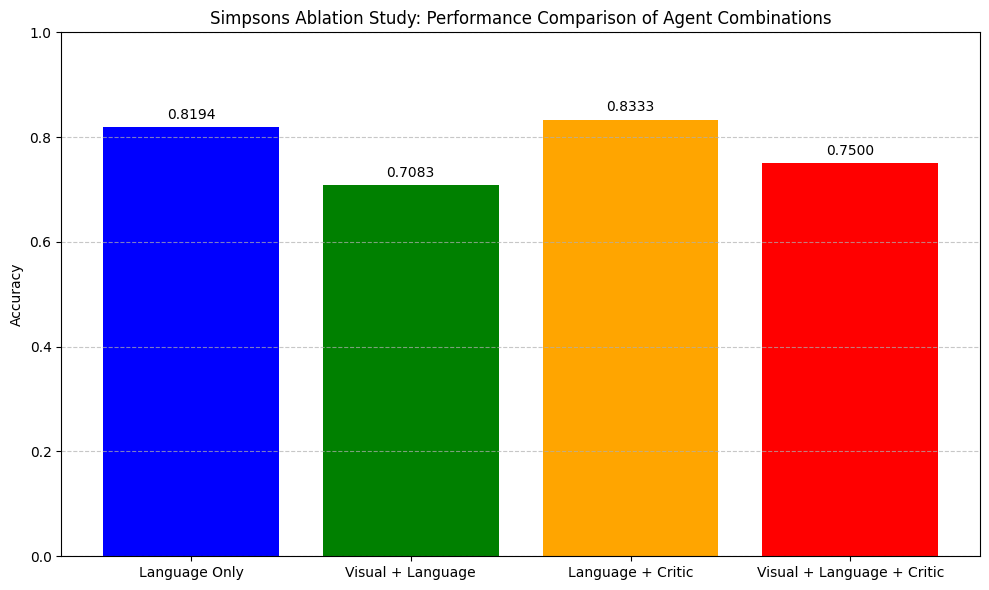

Comparison data saved to: results/blip2/comparison/simpsons_blip2_comparison_20251114_193500.csv


In [ ]:
# Create visualization of ablation results
# Check if we only have visual configuration (no ablation comparison needed)
print(f"Available configurations: {list(all_results.keys())}")

# Check if only visual configuration exists
visual_only_config = (list(all_results.keys()) == ['visual'])
print(f"visual_only_config: {visual_only_config}")

if visual_only_config:
    print("Visual-only configuration detected. Skipping ablation comparison visualization.")
    print("Visual analysis results have been saved to the analysis directory.")
else:
    print("Multiple configurations or non-visual configuration detected. Proceeding with comparison visualization...")
    # Check if all_accuracies has values from current experiments
    if not all_accuracies:
        print("No accuracy results from current experiments.")
        print("Please run the ablation study experiments first before generating visualization.")

    # Use current experiment results if available
    # Safely access the global accuracies variable if it exists
    if 'accuracies' in globals():
        local_accuracies = globals()['accuracies'] if globals()['accuracies'] else []
    else:
        local_accuracies = []

    if not all_accuracies and local_accuracies:
        # Use the current experiment's results if available
        avg_accuracy = np.mean(local_accuracies) if local_accuracies else 0
        config_name = ''
        if ENABLE_VISUAL_AGENT:
            config_name += 'visual_'
        if ENABLE_LANGUAGE_AGENT:
            config_name += 'language'
        if ENABLE_CRITIC_AGENT:
            config_name += '_critic'
        
        if config_name:
            all_accuracies[config_name] = float(f"{avg_accuracy:.4f}")
            print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

    # Only proceed with visualization if we have results
    if all_accuracies:
        # Create the results dictionary for visualization
        results = {
            "Language Only": all_accuracies.get('language', 0),
            "Visual + Language": all_accuracies.get('visual_language', 0),
            "Language + Critic": all_accuracies.get('language_critic', 0),
            "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
        }

        # Print the values we're using
        print("\nAccuracy values used for visualization:")
        for config, accuracy in results.items():
            print(f"{config}: {accuracy:.4f}")

        # Generate timestamp for unique figure name
        timestamp = time.strftime("%Y%m%d_%H%M%S")

        # Create figure save directory
        figures_dir = os.path.join(os.getcwd(), "results", "blip2", "saved_figures")
        os.makedirs(figures_dir, exist_ok=True)

        # Create the visualization
        plt.figure(figsize=(10, 6))
        bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
        plt.ylim(0, 1.0)
        plt.ylabel('Accuracy')
        plt.title('Simpsons Ablation Study: Performance Comparison of Agent Combinations')

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.4f}', ha='center', va='bottom')

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # Save the figure with proper naming convention in results/blip2/saved_figures
        figure_path = os.path.join(figures_dir, f"simpsons_blip2_comparison_{timestamp}.png")
        plt.savefig(figure_path, dpi=300)
        print(f"Visualization saved to: {figure_path}")

        plt.show()

        # Save the comparison results to CSV
        comparison_df = pd.DataFrame([
            {'Configuration': config, 'Accuracy': accuracy}
            for config, accuracy in results.items()
        ])

        comparison_path = f"results/blip2/comparison/simpsons_blip2_comparison_{timestamp}.csv"
        os.makedirs("results/blip2/comparison", exist_ok=True)
        comparison_df.to_csv(comparison_path, index=False)
        print(f"Comparison data saved to: {comparison_path}")
    else:
        print("Skipping visualization - no experiment results available.")
